In [10]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Data Setup

In [2]:
# Read merged data
file_path = "data/intermediate/anes_individual_level.csv"
df = pd.read_csv(file_path, low_memory=False)

In [3]:
# Filter relevant variables for bar charts
bar_vars = [
    'year',
    'trust_gov_right_d',
    'gov_for_all_d',
    'gov_waste_d',
    'crooked_officials_d',
    'trust_gov_index_d'  
]

df_bar = df[bar_vars]
df_bar = df_bar.groupby('year').mean().reset_index()

In [4]:
df_bar

,year,trust_gov_right_d,gov_for_all_d,gov_waste_d,crooked_officials_d,trust_gov_index_d
0,1948,NaN,NaN,NaN,NaN,NaN
1,1952,NaN,NaN,NaN,NaN,NaN
2,1954,NaN,NaN,NaN,NaN,NaN
3,1956,NaN,NaN,NaN,NaN,NaN
4,1958,0.751466,NaN,0.539483,0.745673,0.501784
5,1960,NaN,NaN,NaN,NaN,NaN
6,1962,NaN,NaN,NaN,NaN,NaN
7,1964,0.777388,0.691386,0.519462,0.699928,0.578363
8,1966,0.679123,0.615036,NaN,NaN,0.612648
9,1968,0.627481,0.564356,0.394194,0.736555,0.461194


In [5]:
# Define trust variable list for average in the loop
trust_vars = [
    'trust_gov_right_d',
    'gov_for_all_d',
    'gov_waste_d',
    'crooked_officials_d',
    'trust_gov_index_d'  
]

df_bar = df_bar.groupby('year').mean().reset_index()

# Graph Plotting

In [12]:
# Set output directory
output_dir = "figures/bar_charts"
os.makedirs(output_dir, exist_ok=True)

In [14]:
# Major ticks every 10 years from 1960 to 2020
xticks_major = list(range(1960, 2030, 10))

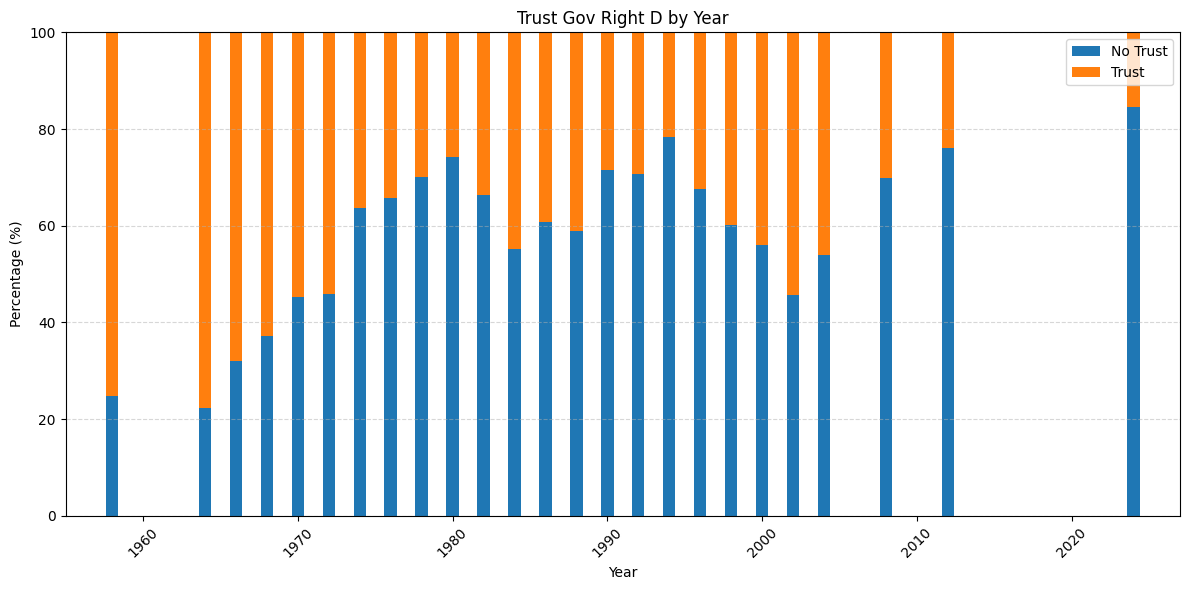

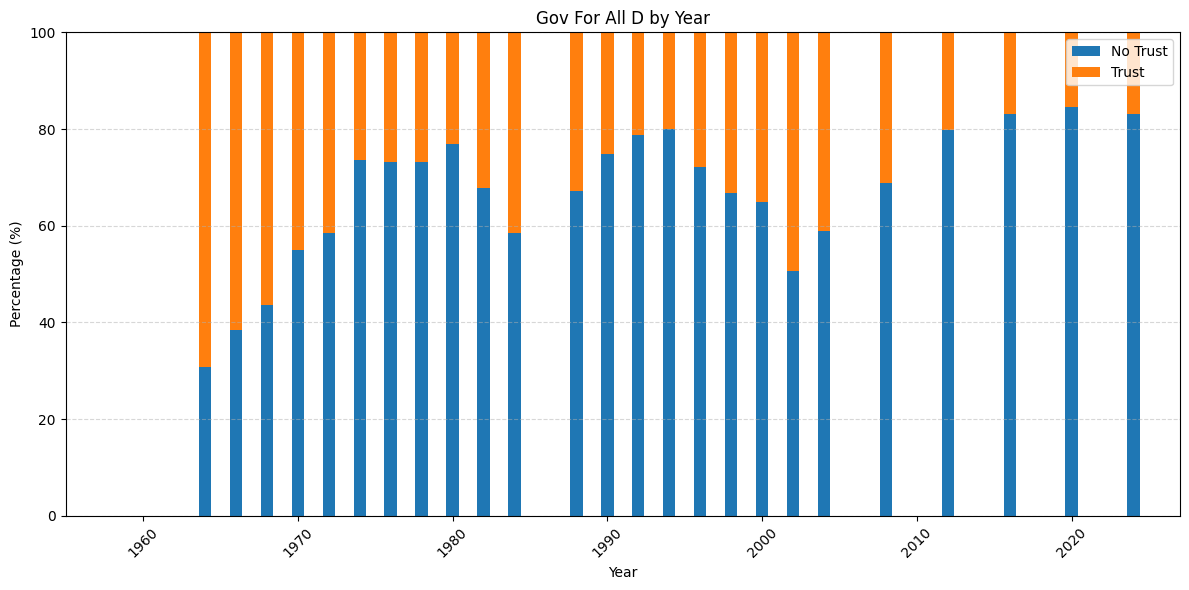

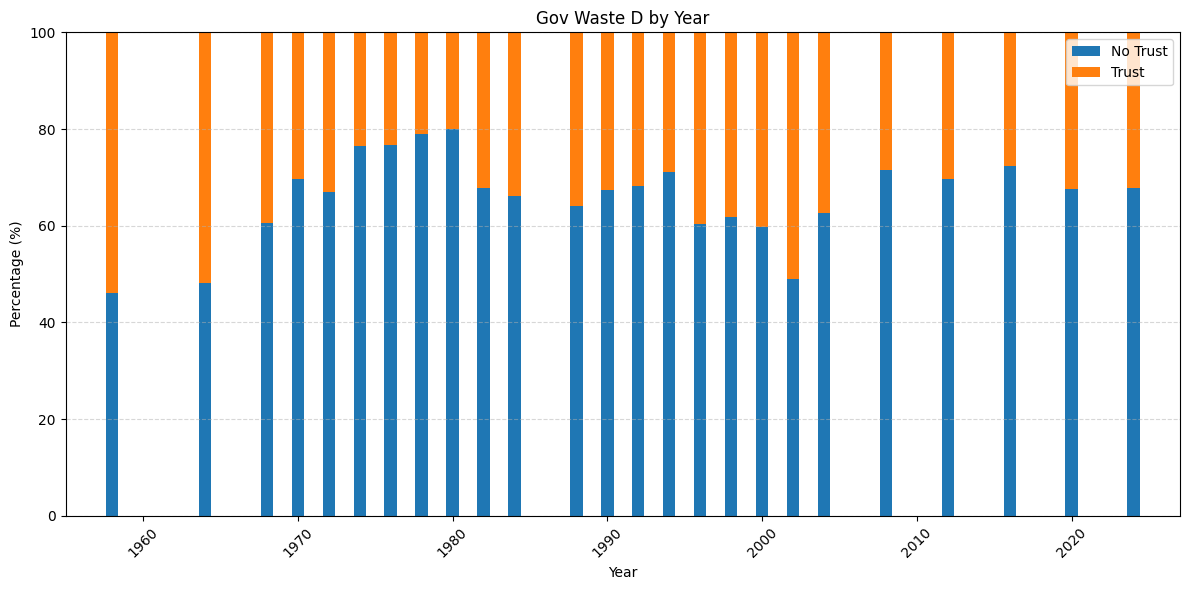

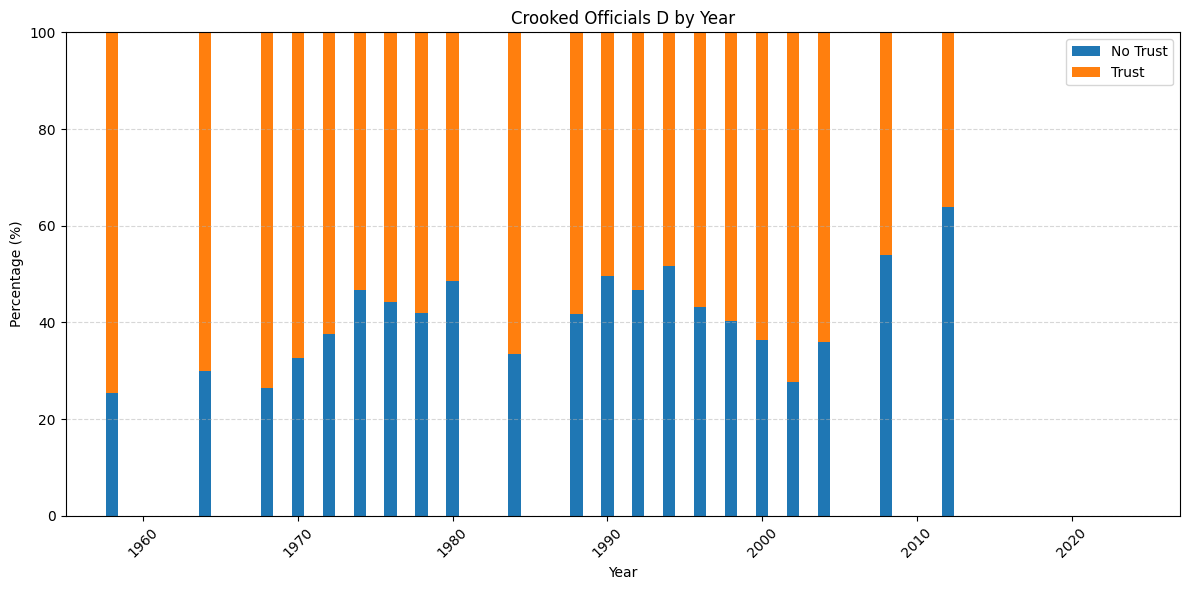

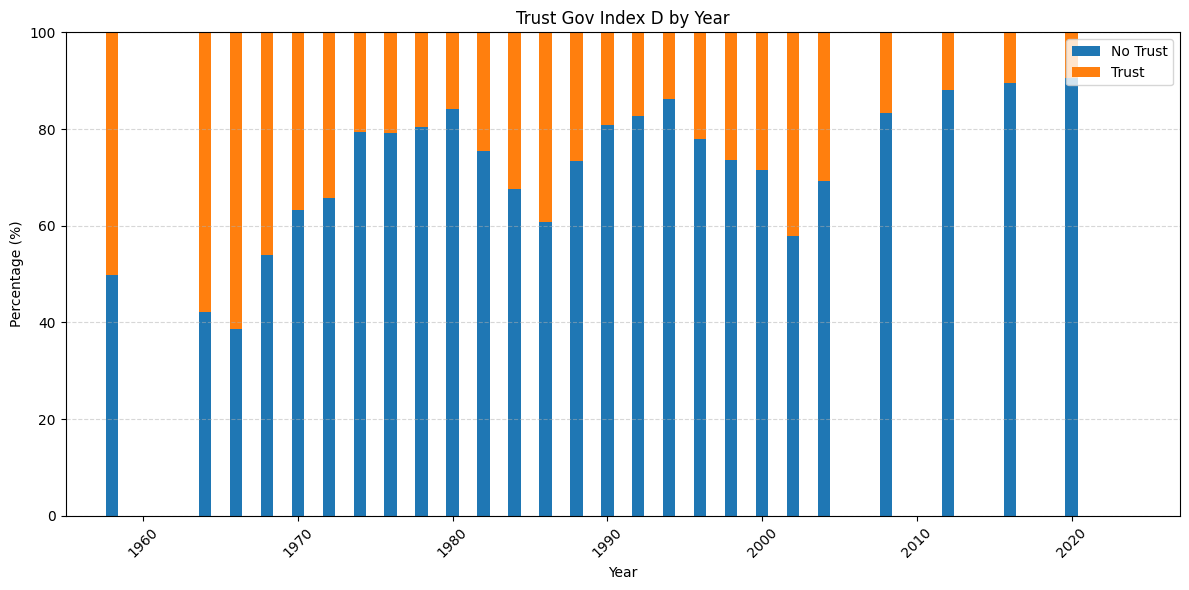

In [19]:
# Main plotting loop
for var in trust_vars:
    # Keep full year axis, but allow NaN bars
    summary = (
        df_bar.loc[:, [year_col, var]]
        .assign(**{year_col: lambda d: d[year_col].astype(int)})
        .sort_values(year_col)
    )

    # Convert to percentages (NaN stays NaN)
    summary['Trust'] = (summary[var] * 100).clip(0, 100)
    summary['No_Trust'] = 100 - summary['Trust']

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(
        summary[year_col],
        summary['No_Trust'],
        label='No Trust'
    )

    ax.bar(
        summary[year_col],
        summary['Trust'],
        bottom=summary['No_Trust'],
        label='Trust'
    )

    # Shared x-axis limits (keep full range incl. 1958 & 2024)
    ax.set_xlim(1955,2027)

    # Show only decade ticks
    ax.set_xticks(xticks_major)
    ax.set_xticklabels(xticks_major)

    ax.tick_params(axis='x', rotation=45)


    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 100)

    ax.set_title(f'{var.replace("_", " ").title()} by Year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Percentage (%)')

    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    fig.tight_layout()

    output_path = os.path.join(output_dir, f"{var}_bar.png")
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)